<a href="https://www.kaggle.com/code/sonawanelalitsunil/indian-street-food-delights-ml-88-31?scriptVersionId=272039044" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/indian-street-food-dataset/indian_food.csv


In [2]:
df = pd.read_csv("/kaggle/input/indian-street-food-dataset/indian_food.csv")

In [3]:
df.head()

,name,ingredients,diet,prep_time,cook_time,flavor_profile,course,state,region
0,Balu shahi,"Maida flour, yogurt, oil, sugar",vegetarian,45,25,sweet,dessert,West Bengal,East
1,Boondi,"Gram flour, ghee, sugar",vegetarian,80,30,sweet,dessert,Rajasthan,West
2,Gajar ka halwa,"Carrots, milk, sugar, ghee, cashews, raisins",vegetarian,15,60,sweet,dessert,Punjab,North
3,Ghevar,"Flour, ghee, kewra, milk, clarified butter, su...",vegetarian,15,30,sweet,dessert,Rajasthan,West
4,Gulab jamun,"Milk powder, plain flour, baking powder, ghee,...",vegetarian,15,40,sweet,dessert,West Bengal,East


In [4]:
df.tail()

,name,ingredients,diet,prep_time,cook_time,flavor_profile,course,state,region
250,Til Pitha,"Glutinous rice, black sesame seeds, gur",vegetarian,5,30,sweet,dessert,Assam,North East
251,Bebinca,"Coconut milk, egg yolks, clarified butter, all...",vegetarian,20,60,sweet,dessert,Goa,West
252,Shufta,"Cottage cheese, dry dates, dried rose petals, ...",vegetarian,-1,-1,sweet,dessert,Jammu & Kashmir,North
253,Mawa Bati,"Milk powder, dry fruits, arrowroot powder, all...",vegetarian,20,45,sweet,dessert,Madhya Pradesh,Central
254,Pinaca,"Brown rice, fennel seeds, grated coconut, blac...",vegetarian,-1,-1,sweet,dessert,Goa,West


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255 entries, 0 to 254
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   name            255 non-null    object
 1   ingredients     255 non-null    object
 2   diet            255 non-null    object
 3   prep_time       255 non-null    int64 
 4   cook_time       255 non-null    int64 
 5   flavor_profile  255 non-null    object
 6   course          255 non-null    object
 7   state           255 non-null    object
 8   region          254 non-null    object
dtypes: int64(2), object(7)
memory usage: 18.1+ KB


In [6]:
df.describe()

,prep_time,cook_time
count,255.000000,255.000000
mean,31.105882,34.529412
std,72.554409,48.265650
min,-1.000000,-1.000000
25%,10.000000,20.000000
50%,10.000000,30.000000
75%,20.000000,40.000000
max,500.000000,720.000000


In [7]:
df.dtypes

name              object
ingredients       object
diet              object
prep_time          int64
cook_time          int64
flavor_profile    object
course            object
state             object
region            object
dtype: object

In [8]:
df.shape

(255, 9)

In [9]:
df.columns

Index(['name', 'ingredients', 'diet', 'prep_time', 'cook_time',
       'flavor_profile', 'course', 'state', 'region'],
      dtype='object')

In [10]:
df.isnull().sum()

name              0
ingredients       0
diet              0
prep_time         0
cook_time         0
flavor_profile    0
course            0
state             0
region            1
dtype: int64

In [11]:
df.duplicated().sum()

0

In [12]:
df.nunique()

name              255
ingredients       252
diet                2
prep_time          22
cook_time          19
flavor_profile      5
course              4
state              25
region              7
dtype: int64

## Data visualizations 

In [13]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

print("✅ Columns Loaded:", df.columns.tolist(), "\n")

# Check basic info
print(df.info())
print("\n📈 Missing Values:\n", df.isnull().sum())
print("\n🧾 Sample Data:\n", df.head())

✅ Columns Loaded: ['name', 'ingredients', 'diet', 'prep_time', 'cook_time', 'flavor_profile', 'course', 'state', 'region'] 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255 entries, 0 to 254
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   name            255 non-null    object
 1   ingredients     255 non-null    object
 2   diet            255 non-null    object
 3   prep_time       255 non-null    int64 
 4   cook_time       255 non-null    int64 
 5   flavor_profile  255 non-null    object
 6   course          255 non-null    object
 7   state           255 non-null    object
 8   region          254 non-null    object
dtypes: int64(2), object(7)
memory usage: 18.1+ KB
None

📈 Missing Values:
 name              0
ingredients       0
diet              0
prep_time         0
cook_time         0
flavor_profile    0
course            0
state             0
region            1
dtype: int64

🧾 Sample Data:
  

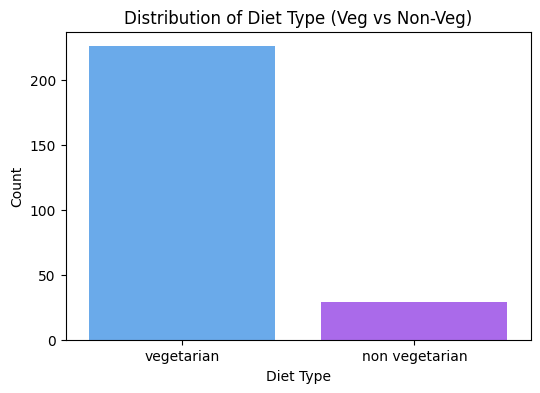

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='diet', palette='cool')
plt.title("Distribution of Diet Type (Veg vs Non-Veg)")
plt.xlabel("Diet Type")
plt.ylabel("Count")
plt.show()


🕒 Time Summary:
         prep_time   cook_time
count  255.000000  255.000000
mean    31.105882   34.529412
std     72.554409   48.265650
min     -1.000000   -1.000000
25%     10.000000   20.000000
50%     10.000000   30.000000
75%     20.000000   40.000000
max    500.000000  720.000000


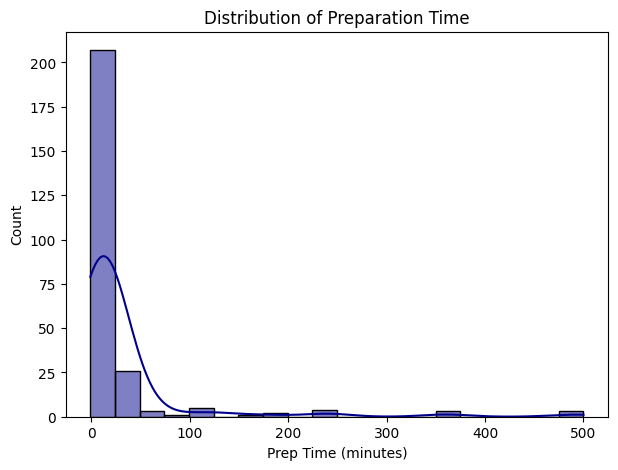

In [15]:
df['prep_time'] = pd.to_numeric(df['prep_time'], errors='coerce')
df['cook_time'] = pd.to_numeric(df['cook_time'], errors='coerce')

time_data = df[['prep_time', 'cook_time']].describe()
print("\n🕒 Time Summary:\n", time_data)

plt.figure(figsize=(7,5))
sns.histplot(df['prep_time'], color='darkblue', kde=True, bins=20)
plt.title("Distribution of Preparation Time")
plt.xlabel("Prep Time (minutes)")
plt.ylabel("Count")
plt.show()

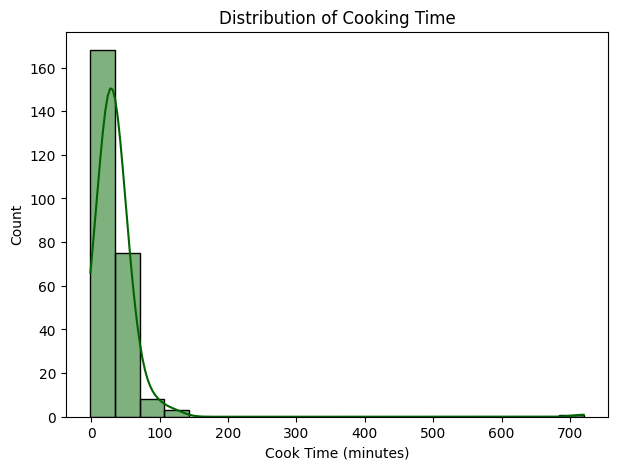

In [16]:
plt.figure(figsize=(7,5))
sns.histplot(df['cook_time'], color='darkgreen', kde=True, bins=20)
plt.title("Distribution of Cooking Time")
plt.xlabel("Cook Time (minutes)")
plt.ylabel("Count")
plt.show()

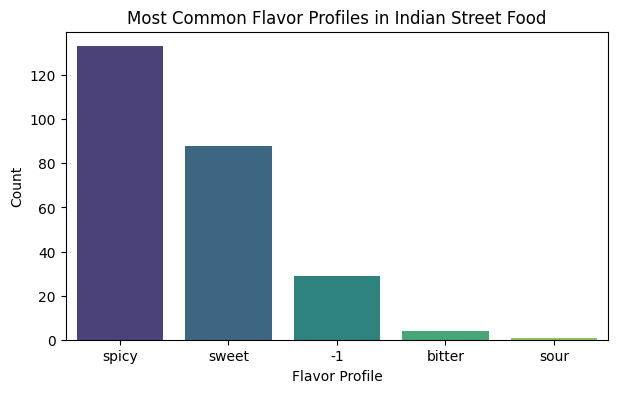

In [17]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='flavor_profile', order=df['flavor_profile'].value_counts().index, palette='viridis')
plt.title("Most Common Flavor Profiles in Indian Street Food")
plt.xlabel("Flavor Profile")
plt.ylabel("Count")
plt.show()

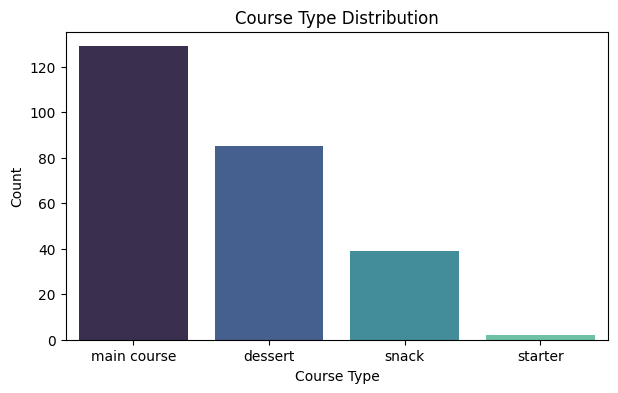

In [18]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='course', order=df['course'].value_counts().index, palette='mako')
plt.title("Course Type Distribution")
plt.xlabel("Course Type")
plt.ylabel("Count")
plt.show()

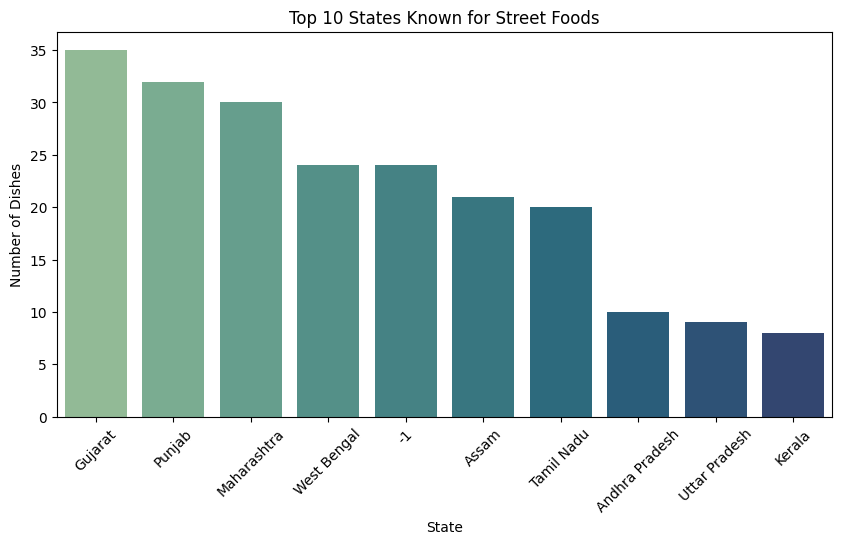

In [19]:
plt.figure(figsize=(10,5))
state_counts = df['state'].value_counts().head(10)
sns.barplot(x=state_counts.index, y=state_counts.values, palette='crest')
plt.title("Top 10 States Known for Street Foods")
plt.xlabel("State")
plt.ylabel("Number of Dishes")
plt.xticks(rotation=45)
plt.show()

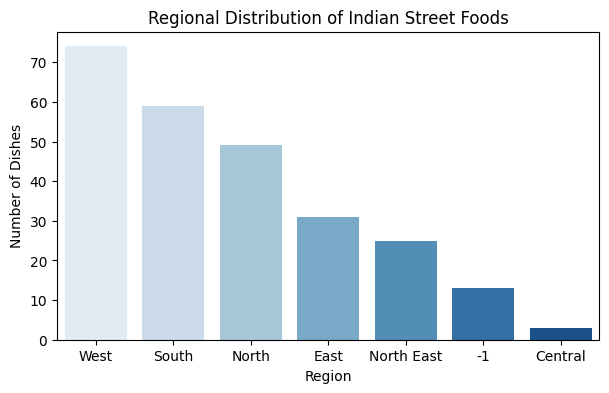

In [20]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='region', order=df['region'].value_counts().index, palette='Blues')
plt.title("Regional Distribution of Indian Street Foods")
plt.xlabel("Region")
plt.ylabel("Number of Dishes")
plt.show()

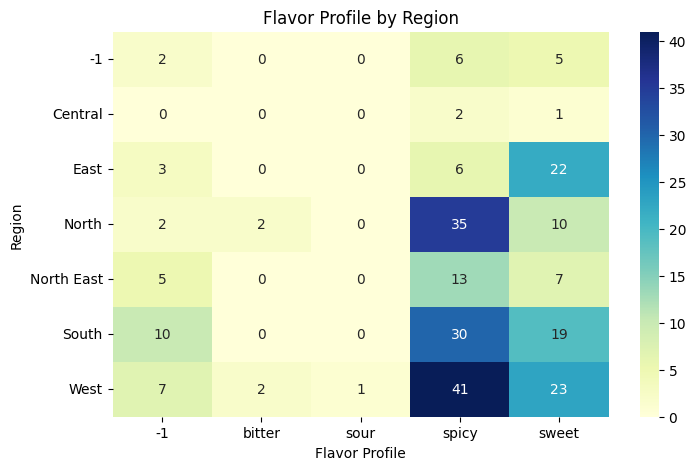

In [21]:
flavor_region = pd.crosstab(df['region'], df['flavor_profile'])
plt.figure(figsize=(8,5))
sns.heatmap(flavor_region, annot=True, cmap='YlGnBu')
plt.title("Flavor Profile by Region")
plt.xlabel("Flavor Profile")
plt.ylabel("Region")
plt.show()

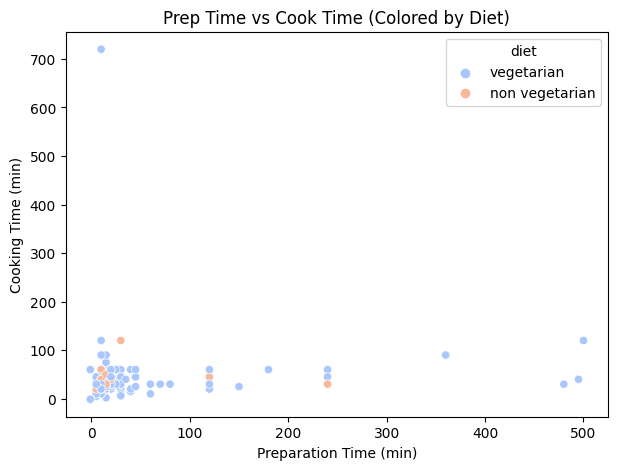

In [22]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='prep_time', y='cook_time', hue='diet', palette='coolwarm')
plt.title("Prep Time vs Cook Time (Colored by Diet)")
plt.xlabel("Preparation Time (min)")
plt.ylabel("Cooking Time (min)")
plt.show()

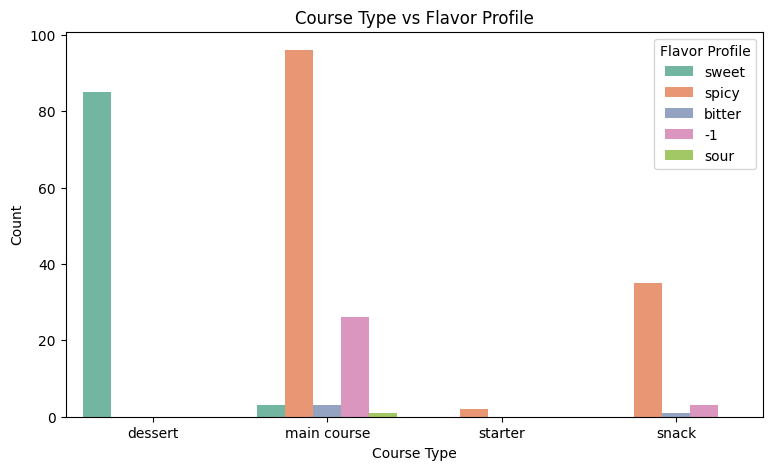

In [23]:
plt.figure(figsize=(9,5))
sns.countplot(data=df, x='course', hue='flavor_profile', palette='Set2')
plt.title("Course Type vs Flavor Profile")
plt.xlabel("Course Type")
plt.ylabel("Count")
plt.legend(title='Flavor Profile')
plt.show()

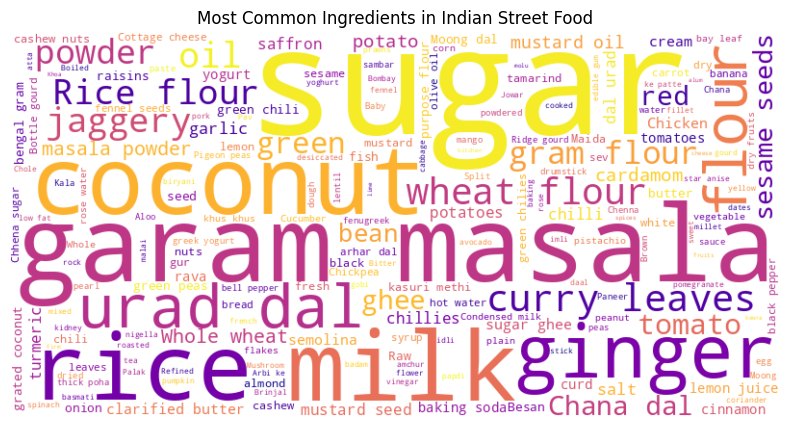


🎯 EDA Visualizations Completed Successfully!


In [24]:
from wordcloud import WordCloud

ingredients_text = " ".join(str(i) for i in df['ingredients'])
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='plasma').generate(ingredients_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Most Common Ingredients in Indian Street Food")
plt.show()

print("\n🎯 EDA Visualizations Completed Successfully!")

## ML algorithms

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [27]:
le = LabelEncoder()
encoded_df = df.copy()
for col in df.columns:
    if df[col].dtype == 'object':
        encoded_df[col] = le.fit_transform(df[col])

In [28]:
X = encoded_df.drop('region', axis=1)
y = encoded_df['region']

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [30]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC()
}

In [31]:
accuracy_results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100
    accuracy_results[name] = round(acc, 2)

In [32]:
accuracy_df = pd.DataFrame(list(accuracy_results.items()), columns=['Model', 'Accuracy (%)'])
print("\n📊 Model Accuracy Comparison:\n")
print(accuracy_df)


📊 Model Accuracy Comparison:

                 Model  Accuracy (%)
0  Logistic Regression         49.35
1        Decision Tree         88.31
2        Random Forest         70.13
3    Gradient Boosting         87.01
4          Naive Bayes         49.35
5                  KNN         28.57
6                  SVM         32.47


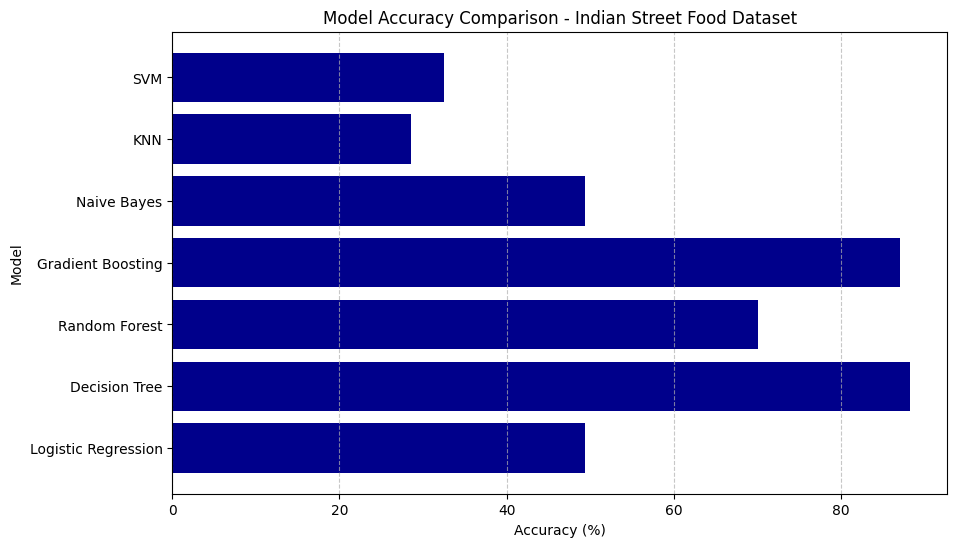

In [33]:
plt.figure(figsize=(10, 6))
plt.barh(accuracy_df['Model'], accuracy_df['Accuracy (%)'], color='darkblue')
plt.xlabel('Accuracy (%)')
plt.ylabel('Model')
plt.title('Model Accuracy Comparison - Indian Street Food Dataset')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## thank you..pls upvote!!!